In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [9]:
class SinusoidalTimeEmbedding(nn.Module):

    def __init__(self, dim):
        super().__init__()
        self.dim = dim


    def forward(self, t):
        device = t.device
        half = self.dim // 2
        emb = torch.exp(
            torch.arange(half, device=device) * -(torch.log(torch.tensor(10000.0)) / (half - 1))
        )
        emb = t[:, None] * emb[None, :]
        return torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)


In [10]:
class ResBlock(nn.Module):

    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()


    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        emb = self.emb_proj(emb)[:, :, None, None]
        h = h + emb
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

In [18]:
class Down(nn.Module):

    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.res = ResBlock(in_ch, out_ch, emb_dim)
        self.down = nn.Conv2d(out_ch, out_ch, 4, 2, 1)


    def forward(self, x, emb):
        x = self.res(x, emb)
        return self.down(x), x


class Up(nn.Module):

    def __init__(self, in_ch, skip_ch, out_ch, emb_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1)
        self.res = ResBlock(out_ch + skip_ch, out_ch, emb_dim)


    def forward(self, x, skip, emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.res(x, emb)



In [20]:
class ConditionalUNet(nn.Module):

    def __init__(self, num_classes=10, time_dim=256):
        super().__init__()

        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU()
        )

        self.class_embed = nn.Embedding(num_classes, time_dim)

        self.init_conv = nn.Conv2d(1, 64, 3, padding=1)

        self.down1 = Down(64, 128, time_dim)
        self.down2 = Down(128, 256, time_dim)

        self.mid = ResBlock(256, 256, time_dim)

        self.up2 = Up(in_ch=256, skip_ch=256, out_ch=128, emb_dim=time_dim)
        self.up1 = Up(in_ch=128, skip_ch=128, out_ch=64, emb_dim=time_dim)

        self.out_norm = nn.GroupNorm(8, 64)
        self.out_conv = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t, y):
        emb = self.time_mlp(t) + self.class_embed(y)

        x = self.init_conv(x)

        x, skip1 = self.down1(x, emb)
        x, skip2 = self.down2(x, emb)

        x = self.mid(x, emb)

        x = self.up2(x, skip2, emb)
        x = self.up1(x, skip1, emb)

        return self.out_conv(F.silu(self.out_norm(x)))


In [16]:
class Diffusion:

    def __init__(self, timesteps=1000, device="cuda"):
        self.timesteps = timesteps
        self.device = device

        self.betas = torch.linspace(1e-4, 0.02, timesteps).to(device)
        self.alphas = 1.0 - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)


    def noise_images(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        noise = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus * noise, noise


    def sample_timesteps(self, n):
        return torch.randint(0, self.timesteps, (n,)).to(self.device)


    def sample(self, model, n, labels):
        model.eval()
        x = torch.randn((n, 1, 28, 28)).to(self.device)

        for i in reversed(range(self.timesteps)):
            t = torch.full((n,), i, device=self.device, dtype=torch.long)
            with torch.no_grad():
                predicted_noise = model(x, t, labels)

            alpha = self.alphas[t][:, None, None, None]
            alpha_hat = self.alpha_hat[t][:, None, None, None]
            beta = self.betas[t][:, None, None, None]

            noise = torch.randn_like(x) if i > 0 else torch.zeros_like(x)
            x = (1 / torch.sqrt(alpha)) * (
                x - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * predicted_noise
            ) + torch.sqrt(beta) * noise

        model.train()
        return x


In [21]:
import os
import torch

def save_checkpoint(model, optimizer, epoch, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict()
    }, path)


def load_checkpoint(path, model, optimizer=None, device="cpu"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt["epoch"]


In [22]:
import torchvision.utils as vutils
import matplotlib.pyplot as plt


@torch.no_grad()
def sample_and_save(model, diffusion, device, epoch, n=16):
    model.eval()

    labels = torch.arange(0, n, device=device) % 10
    samples = diffusion.sample(model, n=n, labels=labels)

    samples = (samples + 1) / 2
    grid = vutils.make_grid(samples, nrow=4)

    os.makedirs("diffusion_model_mnist/samples", exist_ok=True)
    path = f"diffusion_model_mnist/samples/epoch_{epoch:04d}.png"

    plt.figure(figsize=(4, 4))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis("off")
    plt.savefig(path)
    plt.close()

    model.train()


In [24]:
from tqdm import tqdm
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

batch_size = 128
dataset = datasets.MNIST(root="diffusion_model_mnist/data", train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

model = ConditionalUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
diffusion = Diffusion(device=device)

epochs = 30

save_every = 5
sample_every = 5
start_epoch = 0

# start_epoch = load_checkpoint("checkpoints/latest.pt", model, optimizer, device)

for epoch in range(start_epoch, epochs):
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        t = diffusion.sample_timesteps(images.size(0))
        noisy_images, noise = diffusion.noise_images(images, t)

        predicted_noise = model(noisy_images, t, labels)
        loss = F.mse_loss(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pbar.set_postfix(loss=loss.item())

    if (epoch + 1) % save_every == 0:
        save_checkpoint(
            model,
            optimizer,
            epoch + 1,
            f"diffusion_model_mnist/checkpoints/model_epoch_{epoch+1:04d}.pt"
        )
        save_checkpoint(
            model,
            optimizer,
            epoch + 1,
            "diffusion_model_mnist/checkpoints/latest.pt"
        )

    # inference
    if (epoch + 1) % sample_every == 0:
        sample_and_save(model, diffusion, device, epoch + 1)


Epoch 5/30: 100%|████████████████| 469/469 [27:21<00:00,  3.50s/it, loss=0.0252]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Epoch 10/30: 100%|███████████████| 469/469 [27:27<00:00,  3.51s/it, loss=0.0206]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Epoch 15/30: 100%|███████████████| 469/469 [27:33<00:00,  3.53s/it, loss=0.0303]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Epoch 20/30: 100%|████████████████| 469/469 [27:39<00:00,  3.54s/it, loss=0.024]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Epoch 25/30: 100%|███████████████| 469/469 [27:52<00:00,  3.57s/it, loss=0.0205]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Epoch 30/30: 100%|███████████████| 469/469 [2

Сгенерированные цифры: [1, 5, 1, 3, 2, 0, 5, 4, 0, 2, 5, 1, 2, 8, 5, 0]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


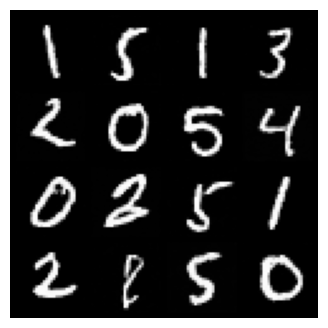

In [25]:
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

n = 16
labels = torch.randint(0, 10, (n,), device=device)

print("Сгенерированные цифры:", labels.cpu().tolist())

samples = diffusion.sample(model, n=n, labels=labels)

# привести в [0,1]
samples = (samples + 1) / 2

grid = vutils.make_grid(samples, nrow=4)

plt.figure(figsize=(4,4))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.show()
